(1)

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_excel('winequality-red.xlsx')

In [ ]:
data.head()

,A,B,C,D,E,F,G,H,I,J,K,L
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
data.describe()

,A,B,C,D,E,F,G,H,I,J,K,L
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


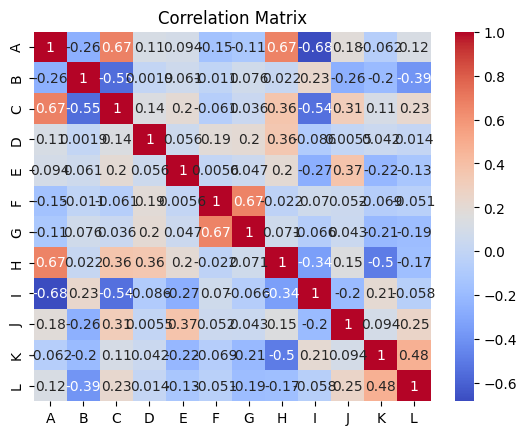

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

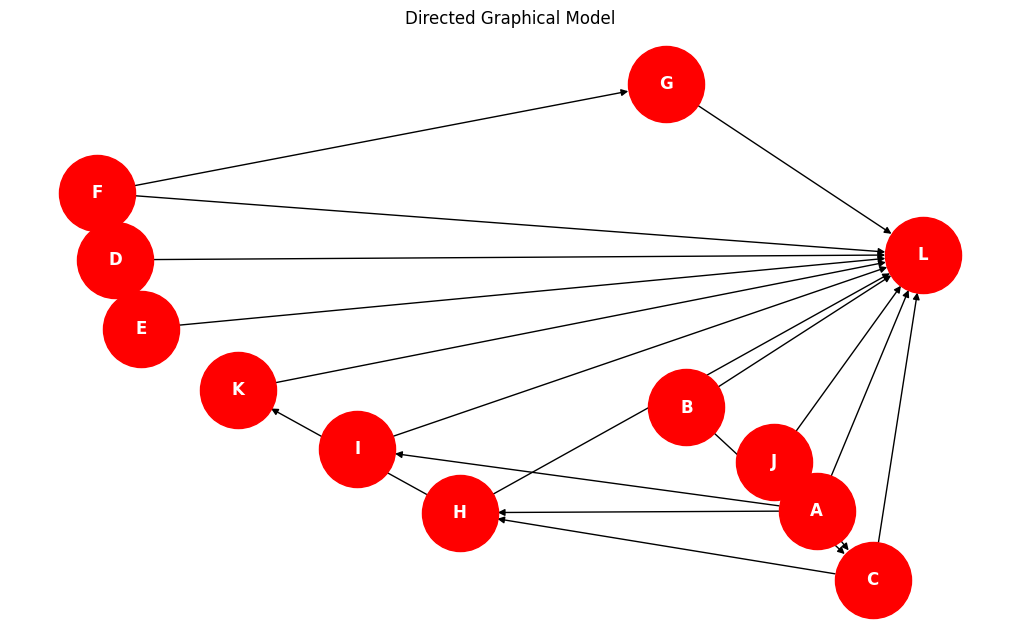

In [ ]:
import networkx as nx

# Create a directed graph
dgm = nx.DiGraph()

# Add nodes
nodes = ['A','B','C','D','E','F','G','H','I','J','K','L']

dgm.add_nodes_from(nodes)

# Add edges
edges = [('A','C'),
         ('A','H'),
         ('A','I'),
         ('A','L'),
         ('B','C'),
         ('B','L'),
         ('C','H'),
         ('C','L'),
         ('D','L'),
         ('E','L'),
         ('F','G'),
         ('F','L'),
         ('G','L'),
         ('H','K'),
         ('H','L'),
         ('I','L'),
         ('J','L'),
         ('K','L'),
         ]

dgm.add_edges_from(edges)

# Draw the directed graph
plt.figure(figsize=(10, 6))
nx.draw(dgm, with_labels=True, node_size=3000,
        node_color='red', font_color='white', font_weight='bold')
plt.title('Directed Graphical Model')
plt.show()

(2)

**Conditional Independence Rules**
*   A ⊥ K | H
*   C ⊥ K | H
*   C ⊥ I | A
*   H ⊥ I | A
*   A ⊥ B



(3)

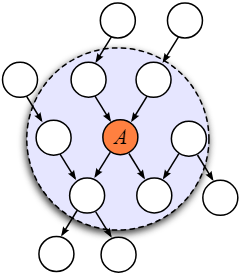

In [ ]:
# Markov Blanket of a node X
# Parents of X
# Children of X
# Co-Parents of X

from pgmpy.models import BayesianModel

# Add edges
edges = [('A','C'),
         ('A','H'),
         ('A','I'),
         ('A','L'),
         ('B','C'),
         ('B','L'),
         ('C','H'),
         ('C','L'),
         ('D','L'),
         ('E','L'),
         ('F','G'),
         ('F','L'),
         ('G','L'),
         ('H','K'),
         ('H','L'),
         ('I','L'),
         ('J','L'),
         ('K','L')]

# Create a model
model = BayesianModel(edges)

# Find Markov Blankets
print("Markov Blanket of C:", model.get_markov_blanket('C'))
print("Markov Blanket of H:", model.get_markov_blanket('H'))
print("Markov Blanket of L:", model.get_markov_blanket('L'))

Markov Blanket of C: ['H', 'I', 'F', 'L', 'D', 'E', 'J', 'A', 'G', 'K', 'B']
Markov Blanket of H: ['I', 'F', 'C', 'L', 'D', 'E', 'J', 'A', 'G', 'K', 'B']
Markov Blanket of L: ['H', 'I', 'F', 'C', 'D', 'E', 'J', 'A', 'G', 'K', 'B']


In [ ]:
from sklearn.preprocessing import KBinsDiscretizer

# Discretize continuous variables
discretizer = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='uniform')
data_discretized = pd.DataFrame(discretizer.fit_transform(data), columns = data.columns)

In [ ]:
data_discretized.head()

,A,B,C,D,E,F,G,H,I,J,K,L
0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,2.0
1,1.0,2.0,0.0,0.0,0.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0
2,1.0,2.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,1.0,2.0
3,2.0,0.0,2.0,0.0,0.0,1.0,0.0,2.0,1.0,0.0,1.0,3.0
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0,0.0,0.0,2.0


In [ ]:
from pgmpy.estimators import BayesianEstimator
model = BayesianModel(edges)
# Train the model
model.fit(data_discretized, estimator=BayesianEstimator)

In [ ]:
# Display learned CPDs
for cpd in model.get_cpds():
    print("CPD of {variable}:".format(variable=cpd.variable))
    print(cpd)

In [ ]:
from pgmpy.estimators import BicScore
bic = BicScore(data_discretized)
print(bic.score(model))

In [ ]:
from pgmpy.inference import VariableElimination
# Perform inference
infer = VariableElimination(model)
# Query
result = infer.query(variables=['L'], evidence={'A': 0, 'H': 0})
print(result)

In [ ]:
import pickle
# Save the model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Load the model
with open('model.pkl', 'rb') as f:
    model = pickle.load(f)

QUESTION 2

In [ ]:
data2 = pd.read_csv("depression.csv")

In [ ]:
data2.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [ ]:
data2 = data2.fillna(method='ffill')

<ipython-input-6-d7e108345fe2>:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data2 = data2.fillna(method='ffill')


In [ ]:
data2.describe()

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000
mean,70442.149421,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139744,0.585499
std,40641.175216,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437343,0.492645
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35039.000000,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70684.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,105818.000000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,140699.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


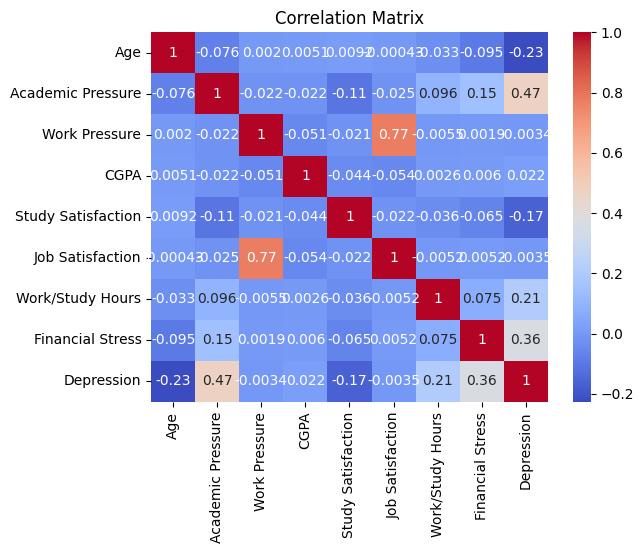

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix
corr_matrix2 = data2[["Age",
                      "Academic Pressure",
                      "Work Pressure",
                      "CGPA",
                      "Study Satisfaction",
                      "Job Satisfaction",
                      "Work/Study Hours",
                      "Financial Stress",
                      "Depression"]].corr()
sns.heatmap(corr_matrix2, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

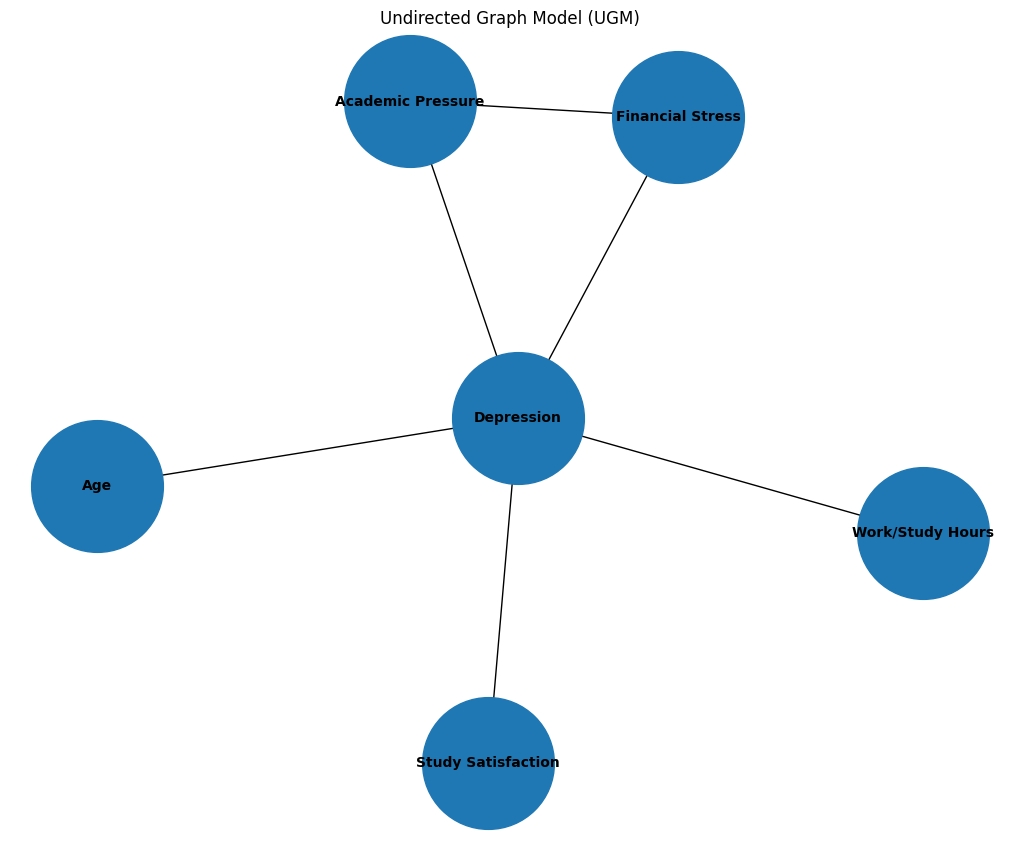

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

ugm = nx.Graph()

# Add our nodes
nodes = [
    "Age",
    "Academic Pressure",
    #"Work Pressure",
    "Study Satisfaction",
    #"Job Satisfaction",
    "Work/Study Hours",
    "Financial Stress",
    "Depression"
]
ugm.add_nodes_from(nodes)

edges = [
    ("Depression", "Age"),
    ("Depression", "Academic Pressure"),
    ("Depression", "Study Satisfaction"),
    ("Depression", "Work/Study Hours"),
    ("Depression", "Financial Stress"),
    ("Academic Pressure", "Financial Stress"),
    #("Work Pressure", "Job Satisfaction")
]
ugm.add_edges_from(edges)

# Draw the graph
plt.figure(figsize=(10, 8))
nx.draw(ugm, with_labels=True, node_size=9000, font_size=10, font_weight="bold")
plt.title("Undirected Graph Model (UGM)")
plt.show()

# 2
Work/Study Hours ⟂ Age | Depression

Study Satisfaction⊥Financial Stress∣Depression

Academic Pressure⊥Study Satisfaction∣Depression

Age⊥Academic Pressure∣Depression

In [ ]:
from pgmpy.models import MarkovNetwork
from pgmpy.factors.discrete import DiscreteFactor
from pgmpy.inference import BeliefPropagation
from pgmpy.models import JunctionTree
from pgmpy.inference import VariableElimination
from sklearn.preprocessing import KBinsDiscretizer
import numpy as np

ModuleNotFoundError: No module named 'pgmpy'

In [ ]:
continuous_columns = ["Age", "Academic Pressure", "Work Pressure", "CGPA",
                      "Study Satisfaction","Job Satisfaction",
                      "Work/Study Hours", "Financial Stress"]
discretizer = KBinsDiscretizer(n_bins=3, encode="ordinal", strategy="uniform")
data2[continuous_columns] = discretizer.fit_transform(data2[continuous_columns])

In [ ]:
data2[continuous_columns]

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
0,1.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,1.0,2.0,0.0,0.0,0.0
2,0.0,1.0,0.0,2.0,2.0,0.0,2.0,0.0
3,0.0,1.0,0.0,1.0,1.0,0.0,1.0,2.0
4,0.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...
27896,0.0,2.0,0.0,1.0,2.0,0.0,1.0,0.0
27897,0.0,1.0,0.0,2.0,1.0,0.0,0.0,1.0
27898,0.0,1.0,0.0,1.0,2.0,0.0,2.0,0.0
27899,0.0,2.0,0.0,2.0,1.0,0.0,2.0,2.0


In [ ]:
nodes = [
    "Age",
    "Academic Pressure",
    "Study Satisfaction",
    "Work/Study Hours",
    "Financial Stress",
    "Depression"
]

edges = [
    ("Depression", "Age"),
    ("Depression", "Academic Pressure"),
    ("Depression", "Study Satisfaction"),
    ("Depression", "Work/Study Hours"),
    ("Depression", "Financial Stress"),
    ("Academic Pressure", "Financial Stress"),
]

ugm = MarkovNetwork(nodes)
ugm.add_edges_from(edges)
for node in set(ugm.nodes()) - set(nodes):
    ugm.remove_node(node)
print("Nodes in UGM:", ugm.nodes())
print("Edges in UGM:", ugm.edges())

Nodes in UGM: ['Depression', 'Age', 'Academic Pressure', 'Study Satisfaction', 'Work/Study Hours', 'Financial Stress']
Edges in UGM: [('Depression', 'Age'), ('Depression', 'Academic Pressure'), ('Depression', 'Study Satisfaction'), ('Depression', 'Work/Study Hours'), ('Depression', 'Financial Stress'), ('Academic Pressure', 'Financial Stress')]


In [ ]:

joint_counts1 = pd.crosstab(data2["Depression"], data2["Age"]).values
joint_probs1 = joint_counts1 / joint_counts1.sum()


factor1 = DiscreteFactor(
    variables=["Depression", "Age"],
    cardinality=[2, 3],
    values=joint_probs1.flatten()
)

In [ ]:

joint_counts2 = pd.crosstab(data2["Depression"], data2["Academic Pressure"]).values
joint_probs2 = joint_counts2 / joint_counts2.sum()


factor2 = DiscreteFactor(
    variables=["Depression", "Academic Pressure"],
    cardinality=[2, 3],
    values=joint_probs2.flatten()
)

In [ ]:

joint_counts3 = pd.crosstab(data2["Depression"], data2["Study Satisfaction"]).values
joint_probs3 = joint_counts3 / joint_counts3.sum()


factor3 = DiscreteFactor(
    variables=["Depression", "Study Satisfaction"],
    cardinality=[2, 3],
    values=joint_probs3.flatten()
)

In [ ]:

joint_counts4 = pd.crosstab(data2["Depression"], data2["Work/Study Hours"]).values
joint_probs4 = joint_counts4 / joint_counts4.sum()

factor4 = DiscreteFactor(
    variables=["Depression", "Work/Study Hours"],
    cardinality=[2, 3],
    values=joint_probs4.flatten()
)

In [ ]:

joint_counts5 = pd.crosstab(data2["Depression"], data2["Financial Stress"]).values
joint_probs5 = joint_counts5 / joint_counts5.sum()


factor5 = DiscreteFactor(
    variables=["Depression", "Financial Stress"],
    cardinality=[2, 3],
    values=joint_probs5.flatten()
)

In [ ]:

joint_counts6 = pd.crosstab(data2["Academic Pressure"], data2["Financial Stress"]).values
joint_probs6 = joint_counts6 / joint_counts6.sum()


factor6 = DiscreteFactor(
    variables=["Academic Pressure", "Financial Stress"],
    cardinality=[3, 3],
    values=joint_probs6.flatten()
)

NameError: name 'pd' is not defined

In [ ]:
ugm.add_factors(factor1,factor2,factor3,factor4,factor5,factor6)

In [ ]:

print("Is the model valid?", ugm.check_model())

Is the model valid? True


In [ ]:


inference = BeliefPropagation(ugm)

esult = inference.query(variables=["Depression"],
                          evidence={"Age":1,
                                    "Academic Pressure":1,
                                    "Study Satisfaction":1,
                                    "Work/Study Hours":1,
                                    "Financial Stress":1
                                    })
print(result)

+---------------+-------------------+
| Depression    |   phi(Depression) |
+===============+===================+
| Depression(0) |            0.3403 |
+---------------+-------------------+
| Depression(1) |            0.6597 |
+---------------+-------------------+


In [ ]:
# 5) Junction Tree

junction_tree = ugm.to_junction_tree()

# Display the Junction Tree structure (nodes and edges)
junction_tree_nodes = list(junction_tree.nodes())
junction_tree_edges = list(junction_tree.edges())

junction_tree_nodes, junction_tree_edges

([('Depression', 'Study Satisfaction'),
  ('Depression', 'Work/Study Hours'),
  ('Depression', 'Age'),
  ('Depression', 'Financial Stress', 'Academic Pressure')],
 [(('Depression', 'Study Satisfaction'), ('Depression', 'Work/Study Hours')),
  (('Depression', 'Study Satisfaction'), ('Depression', 'Age')),
  (('Depression', 'Study Satisfaction'),
   ('Depression', 'Financial Stress', 'Academic Pressure'))])

In [ ]:

variable_elimination = VariableElimination(ugm)


ve_result = variable_elimination.query(
    variables=["Depression"],
    evidence={
        "Age": 1
    }
)

print(ve_result)


+---------------+-------------------+
| Depression    |   phi(Depression) |
+===============+===================+
| Depression(0) |            0.0004 |
+---------------+-------------------+
| Depression(1) |            0.0012 |
+---------------+-------------------+


In [ ]:

custom_elimination_order = ["Study Satisfaction", "Work/Study Hours", "Financial Stress", "Academic Pressure"]



elimination_order = variable_elimination._get_elimination_order(
    variables=["Depression"],  # Query variables
    evidence={
        "Age": 1
              },
    elimination_order=custom_elimination_order
)

print("Elimination Order:", elimination_order)

Elimination Order: ['Study Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Academic Pressure']


In [ ]:

ve_result = variable_elimination.query(
    variables=["Depression"],
    evidence={
        "Age": 1
    }
)


print("Query Result:", ve_result)

Query Result: +---------------+-------------------+
| Depression    |   phi(Depression) |
+===============+===================+
| Depression(0) |            0.0004 |
+---------------+-------------------+
| Depression(1) |            0.0012 |
+---------------+-------------------+
